# GEX across the most active names: whether the SPY result generalizes and what the intraday live value adds

The SPY notebooks showed that the sign of net gamma exposure at the close describes the next session's range, and that the live book, the previous close's book evaluated at the current spot, tracks the next official print and predicts the next half hour better than the stale value. A scanner over hundreds of names is only useful if those two facts hold across names. This notebook runs the same pipeline on the most active optionable names plus the SPX index book over one year, then pools the tests.

## Universe and data

The 40 most active names from the scanner's universe (ranked by option trading in July 2026, SPY excluded because it has its own notebooks) plus the SPX book (SPX and SPXW roots on the SPX spot, priced European). Window 2025-09-15 to 2026-09-14. Per name and day: `option_history_eod` and `option_history_open_interest` with `expiration="*"` and `max_dte=120`, the stock or index daily bars, and 1-minute bars. Chain rules, engine and GEX formula are those of the SPY notebook; the flat dividend yield per name is a trailing-yield assumption listed in `gexlib.Q_BY_SYMBOL` (0 for names not listed). Single names carry discrete dividends and earnings jumps that the flat-yield model does not see; deep in-the-money contracts quoted below the zero-vol floor are excluded exactly as for SPY. Names with a short option history (recent listings) have fewer days.

In [1]:
import json
import sys
import time
import warnings
import numpy as np
import pandas as pd
warnings.filterwarnings("ignore", category=RuntimeWarning)
sys.path.insert(0, "gex_history")
import gexlib as G
import intraday as I
import cross_section as X
pd.set_option("display.width", 220); pd.set_option("display.max_columns", 40)
spots = sorted(p.stem.split("_")[0] for p in G.CACHE.glob("*_stock_eod.parquet")) + sorted(p.stem.split("_")[0] for p in G.CACHE.glob("*_index_eod.parquet"))
symbols = [s for s in spots if s not in ("spy", "spxw")]
roots = {s: (["spx", "spxw"] if s == "spx" else [s]) for s in symbols}
print(len(symbols), "spot symbols:", " ".join(s.upper() for s in symbols))

41 spot symbols: AAPL AMD AMZN ARM ASML ASTS AVGO BE CRWV DELL DRAM EWY GLD GOOG GOOGL GS IBM INTC IWM META MRVL MSFT MSTR MU NBIS NFLX NVDA ORCL PLTR QQQ SKHY SLV SMH SNDK SOXL SPCX STX TSLA TSM WDC SPX


## Daily GEX per name

Same engine pass per name: chain prep, American IV and gamma on the CPU in fp64, the daily table, and the 81-point spot-grid profile that the intraday live value reads. Each row of the summary is one name.

In [2]:
t0 = time.perf_counter()
runs = [X.run_symbol(s, roots=roots[s], verbose=True) for s in symbols]
summary = pd.DataFrame([r for r in runs if r.get("status") == "ok"]).set_index("symbol")
skipped = [r for r in runs if r.get("status") != "ok"]
print(f"{len(summary)} names in {time.perf_counter() - t0:.0f}s; skipped: {skipped}")
X.XS.mkdir(parents=True, exist_ok=True)
G.save_json({"runs": runs}, X.XS / "symbols.json")
summary[["days", "contracts", "t_iv_s", "share_negative_days", "median_gex_bn", "median_abs_gex_bn", "flip_found_share", "iv_status_ne_0_oi_share"]].style.format(
    {"t_iv_s": "{:.1f}", "share_negative_days": "{:.0%}", "median_gex_bn": "{:+.2f}", "median_abs_gex_bn": "{:.2f}", "flip_found_share": "{:.0%}", "iv_status_ne_0_oi_share": "{:.2%}"})

AAPL   251 days, 125,346 contracts, IV 0.6s, negative 2%, median |GEX| 0.97 billion $, 15.1s


AMD    251 days, 135,062 contracts, IV 0.3s, negative 23%, median |GEX| 0.11 billion $, 12.3s


AMZN   251 days, 116,681 contracts, IV 0.3s, negative 4%, median |GEX| 0.41 billion $, 11.2s


ARM    251 days, 96,136 contracts, IV 0.3s, negative 45%, median |GEX| 0.01 billion $, 10.8s


ASML   251 days, 221,000 contracts, IV 0.9s, negative 31%, median |GEX| 0.04 billion $, 19.5s


...

TSM    251 days, 114,291 contracts, IV 0.5s, negative 33%, median |GEX| 0.08 billion $, 14.5s


WDC    251 days, 118,711 contracts, IV 0.5s, negative 26%, median |GEX| 0.01 billion $, 14.5s


SPX    251 days, 2,704,554 contracts, IV 0.1s, negative 38%, median |GEX| 32.18 billion $, 128.2s


41 names in 728s; skipped: []


,days,contracts,t_iv_s,share_negative_days,median_gex_bn,median_abs_gex_bn,flip_found_share,iv_status_ne_0_oi_share
symbol,,,,,,,,
AAPL,251,125346,0.6,2%,+0.97,0.97,46%,0.33%
AMD,251,135062,0.3,23%,+0.09,0.11,63%,0.06%
AMZN,251,116681,0.3,4%,+0.41,0.41,72%,0.16%
ARM,251,96136,0.3,45%,+0.00,0.01,43%,0.07%
ASML,251,221000,0.9,31%,+0.03,0.04,81%,0.13%
ASTS,251,83987,0.2,43%,+0.00,0.00,38%,0.01%
AVGO,251,158020,0.7,30%,+0.08,0.11,73%,0.09%
BE,251,99486,0.3,22%,+0.01,0.01,18%,0.04%
CRWV,251,106707,0.3,41%,+0.01,0.02,32%,0.01%


## Whether the daily result generalizes

Within each name: mean next-day range after a positive-GEX close against after a negative one, the ratio, and a Mann-Whitney p-value. Then the pooled test on the range relative to the name's own trailing 20-day mean, so names with different vol levels can be stacked.

,n,share_negative,gex_bottom_third_max_bn,gex_top_third_min_bn,range_rel_bottom,range_rel_top,ratio_bottom_over_top,absret_bottom,absret_top,p_mwu
symbol,,,,,,,,,,
AAPL,231,3%,+0.72,+1.11,1.088,0.930,1.17,1.31%,0.81%,0.009
AMD,231,25%,+0.04,+0.13,0.987,0.984,1.00,3.14%,3.82%,0.786
AMZN,231,4%,+0.27,+0.56,1.046,0.954,1.10,1.78%,1.42%,0.144
ARM,231,46%,-0.01,+0.01,1.040,1.060,0.98,2.39%,4.53%,0.704
ASML,231,33%,+0.00,+0.04,1.036,1.009,1.03,2.85%,2.21%,0.429
ASTS,231,45%,-0.00,+0.00,0.925,1.067,0.87,4.90%,6.42%,0.007
AVGO,231,32%,+0.00,+0.15,0.955,0.952,1.00,2.01%,2.19%,0.654
BE,231,24%,+0.00,+0.02,1.010,0.960,1.05,5.61%,4.97%,0.310
CRWV,231,45%,-0.01,+0.02,1.022,0.949,1.08,4.63%,4.73%,0.425


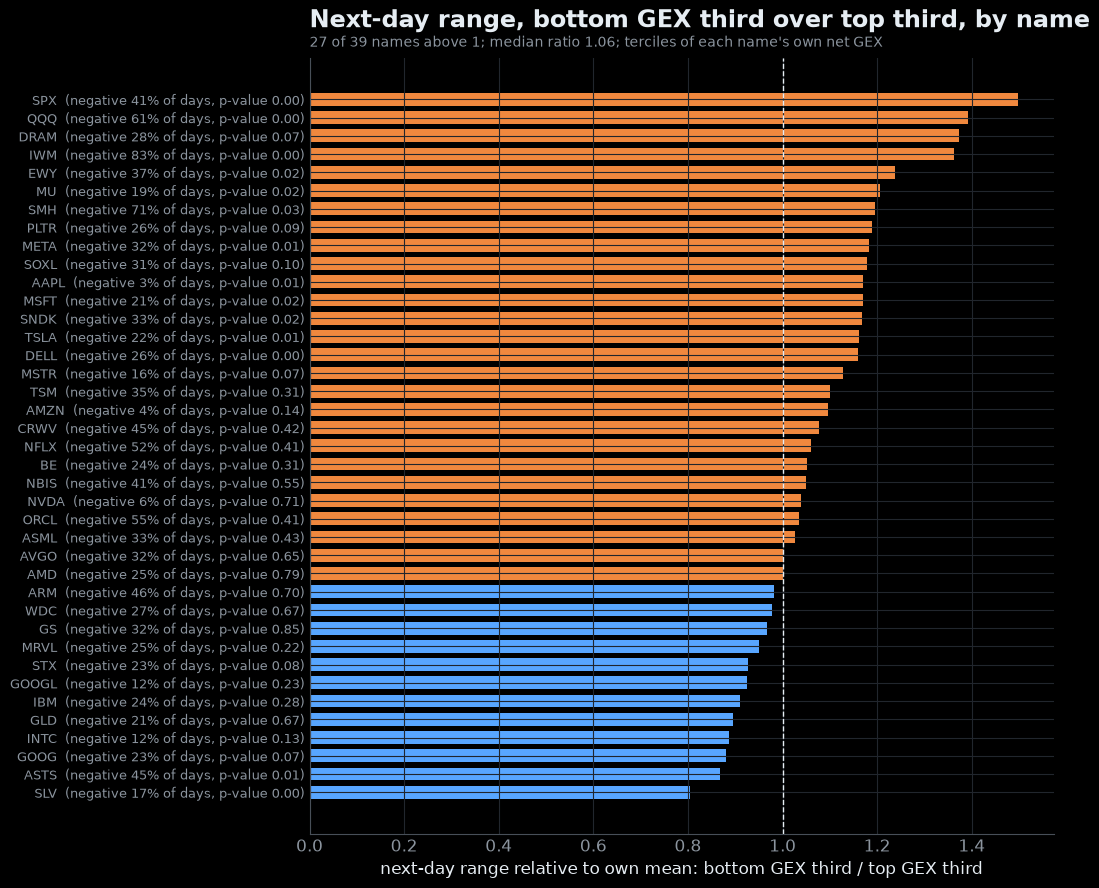

In [3]:
names = list(summary.index.str.lower())
bytercile = X.next_day_by_tercile(names)
_ = X.fig_tercile_by_name(bytercile, G.FIGURES / "f11_tercile_by_name.png")
bytercile.style.format({"share_negative": "{:.0%}", "gex_bottom_third_max_bn": "{:+.2f}", "gex_top_third_min_bn": "{:+.2f}", "range_rel_bottom": "{:.3f}",
                        "range_rel_top": "{:.3f}", "ratio_bottom_over_top": "{:.2f}", "absret_bottom": "{:.2%}", "absret_top": "{:.2%}", "p_mwu": "{:.3f}"})

Single names are call-heavy books that rarely turn negative, so the sign cut leaves few negative days; the table above uses each name's own GEX terciles. The sign cut is shown next for completeness, then the pooled tests.

In [4]:
byname = X.next_day_by_regime(names)
byname.style.format({"share_negative": "{:.0%}", "range_next_pos": "{:.2%}", "range_next_neg": "{:.2%}", "ratio_neg_over_pos": "{:.2f}",
                     "range_rel_pos": "{:.3f}", "range_rel_neg": "{:.3f}", "absret_next_pos": "{:.2%}", "absret_next_neg": "{:.2%}", "p_mwu_range": "{:.3f}"})

,n_pos,n_neg,share_negative,range_next_pos,range_next_neg,ratio_neg_over_pos,range_rel_pos,range_rel_neg,absret_next_pos,absret_next_neg,p_mwu_range
symbol,,,,,,,,,,,
AAPL,245,6,nan%,nan%,nan%,nan,nan,nan,nan%,nan%,nan
AMD,194,57,23%,4.79%,4.68%,0.98,0.989,1.008,3.28%,3.02%,0.548
AMZN,241,10,4%,2.41%,2.60%,1.08,0.999,0.974,1.54%,1.16%,0.428
ARM,138,113,45%,6.15%,5.06%,0.82,1.026,1.005,3.98%,2.72%,0.001
ASML,174,77,31%,2.82%,3.29%,1.17,1.011,1.023,2.08%,2.81%,0.007
ASTS,143,108,43%,9.67%,7.78%,0.81,1.032,0.931,6.12%,4.76%,0.000
AVGO,176,75,30%,3.54%,3.58%,1.01,1.003,0.969,2.15%,2.08%,0.891
BE,196,55,22%,9.12%,10.03%,1.10,0.989,1.018,5.39%,5.69%,0.062
CRWV,147,104,41%,7.35%,7.35%,1.00,0.977,1.023,4.33%,4.70%,0.289


sign cut: {
 "n_pos": 6154,
 "n_neg": 2786,
 "n_names": 41,
 "range_rel_pos": 0.9915783460965361,
 "range_rel_neg": 1.0464466444773246,
 "diff": -0.05486829838078855,
 "ci_lo": -0.07565217562050841,
 "ci_hi": -0.034457015804083876,
 "p_mwu": 4.077886742858526e-08,
 "absret_pos": 0.0281815473522461,
 "absret_neg": 0.03052340626523295
}
tercile cut: {
 "n_bottom": 2980,
 "n_top": 2981,
 "n_names": 41,
 "range_rel_bottom": 1.0457128586110171,
 "range_rel_top": 0.978481023843181,
 "ratio_bottom_over_top": 1.068710412496064,
 "diff": 0.06723183476783612,
 "ci_lo": 0.04401007020559485,
 "ci_hi": 0.0903741299537171,
 "p_mwu": 1.3567213870184297e-08,
 "absret_bottom": 0.030101626253175168,
 "absret_top": 0.028633903231813487
}


next-day relative range by bin, most negative to most positive:
  GEX per dollar traded: [1.019, 0.995, 0.986, 1.019, 1.023]
  GEX z-score against the name's own 60 days: [0.992, 1.005, 1.01, 0.998, 1.012]
  raw net GEX: [1.025, 0.996, 1.008, 1.013, 1.0]


,n,range_rel_next,absret_next,ret_next,key_median,share_negative
bin,,,,,,
0,1871,1.019,2.42%,+0.222%,-1.54e-02,83%
1,1707,0.995,3.83%,+0.201%,6.63e-04,47%
2,1807,0.986,3.55%,+0.274%,7.45e-03,20%
3,1707,1.019,2.87%,+0.109%,1.78e-02,5%
4,1848,1.023,1.88%,-0.044%,5.35e-02,0%


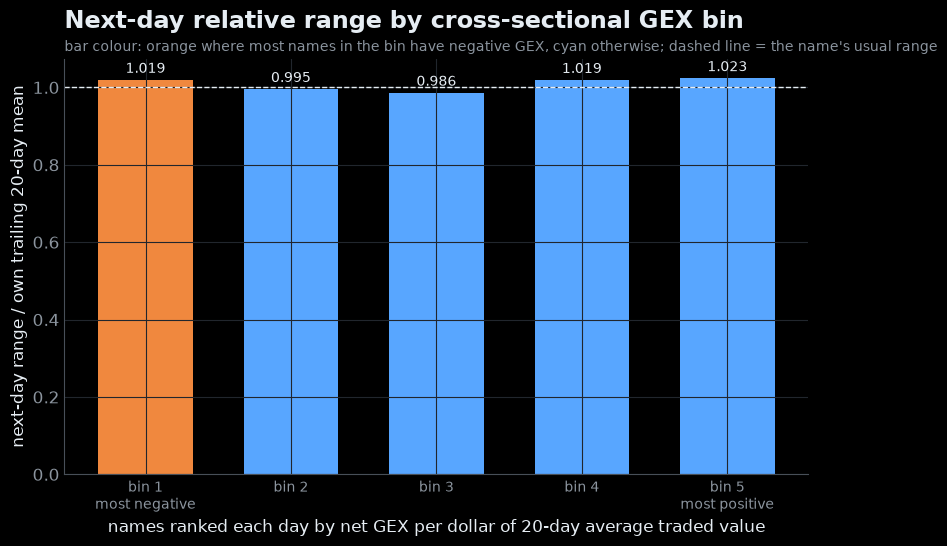

In [5]:
panel = X.pooled_panel(names)
panel = panel[panel.index >= "2025-09-15"]
pooled = X.pooled_regime_test(panel)
pooled_t = X.pooled_tercile_test(panel)
print("sign cut:", json.dumps(pooled, indent=1))
print("tercile cut:", json.dumps(pooled_t, indent=1))
xs = X.cross_sectional_sort(panel, key="gex_per_dv", n_bins=5)
xs_z = X.cross_sectional_sort(panel, key="gex_z", n_bins=5)
xs_raw = X.cross_sectional_sort(panel, key="gex_net_usd", n_bins=5)
_ = X.fig_xs_sort(xs, "net GEX per dollar of 20-day average traded value", G.FIGURES / "f12_cross_sectional_sort.png")
print("next-day relative range by bin, most negative to most positive:")
for lab, t in (("GEX per dollar traded", xs), ("GEX z-score against the name's own 60 days", xs_z), ("raw net GEX", xs_raw)):
    print(f"  {lab}: {[round(v, 3) for v in t['range_rel_next']]}")
xs.style.format({"range_rel_next": "{:.3f}", "absret_next": "{:.2%}", "ret_next": "{:+.3%}", "key_median": "{:.2e}", "share_negative": "{:.0%}"})

## The intraday live value across names

For each name with 1-minute bars: the previous close's book live at each half-hour close (from its profile), the stale print, and the next bucket's adjusted range. Per name: agreement of the live value and of the stale print with the next official GEX sign. Pooled: Spearman on within-name ranks, and the flip-against-same comparison.

/home/will/git/GPU-Quant-Finance/05-pytorch-options-scanning/gex_history/intraday.py:174: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out["share_days_with_any_flip"] = float(d.groupby("date").apply(lambda g: (g["regime_live"] != g["regime_prev"]).any()).mean())


/home/will/git/GPU-Quant-Finance/05-pytorch-options-scanning/gex_history/intraday.py:174: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out["share_days_with_any_flip"] = float(d.groupby("date").apply(lambda g: (g["regime_live"] != g["regime_prev"]).any()).mean())


/home/will/git/GPU-Quant-Finance/05-pytorch-options-scanning/gex_history/intraday.py:174: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out["share_days_with_any_flip"] = float(d.groupby("date").apply(lambda g: (g["regime_live"] != g["regime_prev"]).any()).mean())


/home/will/git/GPU-Quant-Finance/05-pytorch-options-scanning/gex_history/intraday.py:174: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out["share_days_with_any_flip"] = float(d.groupby("date").apply(lambda g: (g["regime_live"] != g["regime_prev"]).any()).mean())


/home/will/git/GPU-Quant-Finance/05-pytorch-options-scanning/gex_history/intraday.py:174: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out["share_days_with_any_flip"] = float(d.groupby("date").apply(lambda g: (g["regime_live"] != g["regime_prev"]).any()).mean())


...

/home/will/git/GPU-Quant-Finance/05-pytorch-options-scanning/gex_history/intraday.py:174: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out["share_days_with_any_flip"] = float(d.groupby("date").apply(lambda g: (g["regime_live"] != g["regime_prev"]).any()).mean())


/home/will/git/GPU-Quant-Finance/05-pytorch-options-scanning/gex_history/cross_section.py:178: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  out["share_days_with_flip"] = float(d.groupby(["symbol", "date"]).apply(lambda g: (g["regime_live"] != g["regime_prev"]).any()).mean())


41 names with intraday panels in 17s
{'n_names': 41, 'n_buckets': 115644, 'n_days': 9637, 'spearman_stale': -0.09296294021530166, 'spearman_live': -0.11501712193924497, 'share_days_with_flip': 0.1364532530870603, 't6_mean': {'sign_agreement_stale': 0.853, 'sign_agreement_live': 0.922, 'corr_level_stale': 0.758, 'corr_level_live': 0.89}}


,n_flipped,n_same,next_range_adj_flipped,next_range_adj_same,diff,ci_lo,ci_hi,p_mwu
prev_negative_flipped_positive,4807.000,29501.000,1.108,1.265,-0.157,-0.176,-0.137,0.000
prev_positive_flipped_negative,5582.000,75754.000,1.228,1.098,0.130,0.114,0.147,0.000


,sign_agreement_stale,sign_agreement_live,corr_level_stale,corr_level_live,live_caught_change
AAPL,0.968,0.992,0.840,0.921,0.750
AMD,0.840,0.928,0.685,0.876,0.600
AMZN,0.944,0.960,0.797,0.940,0.643
ARM,0.876,0.924,0.857,0.932,0.484
ASML,0.788,0.892,0.641,0.799,0.604
ASTS,0.768,0.832,0.777,0.877,0.293
AVGO,0.836,0.916,0.769,0.906,0.585
BE,0.864,0.908,0.780,0.871,0.324
CRWV,0.860,0.904,0.829,0.914,0.400
DELL,0.896,0.952,0.735,0.884,0.654


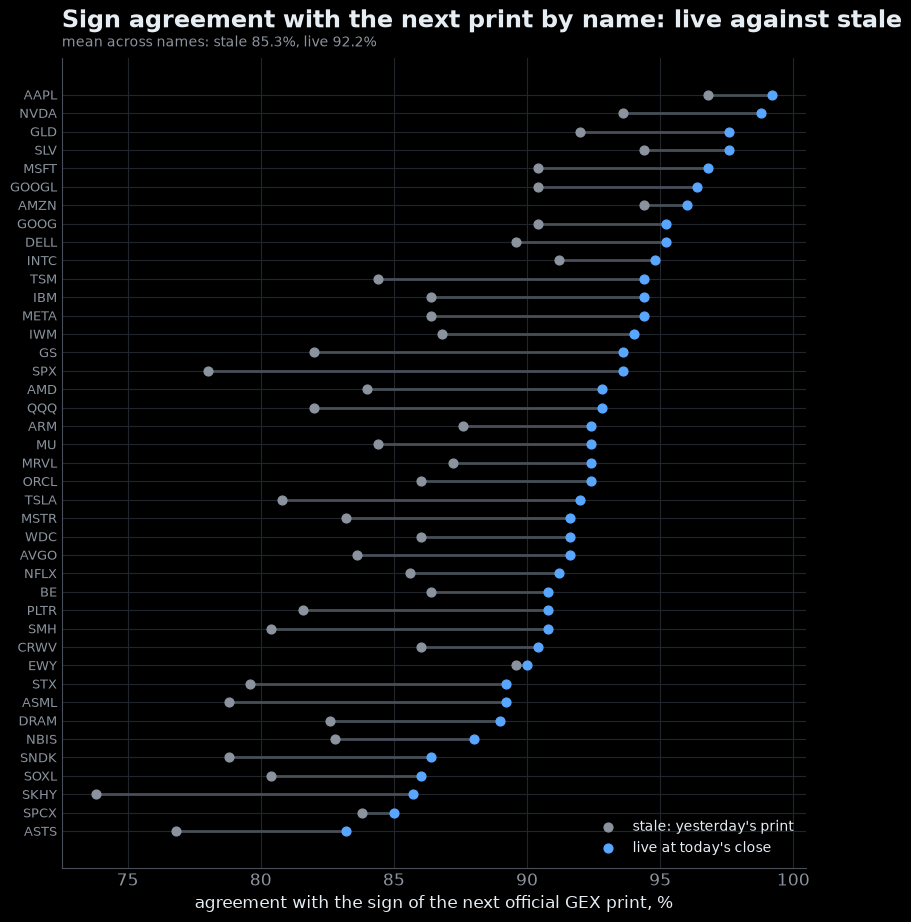

In [6]:
t0 = time.perf_counter()
intra = [r for r in (X.intraday_for_symbol(s) for s in names) if r is not None]
pooled_intra = X.pooled_intraday(intra)
print(f"{len(intra)} names with intraday panels in {time.perf_counter() - t0:.0f}s")
print({k: v for k, v in pooled_intra.items() if k not in ("t6_by_name", "flip_vs_same")})
display(pd.DataFrame(pooled_intra["flip_vs_same"]).T.style.format("{:.3f}"))
_ = X.fig_live_by_name(pooled_intra["t6_by_name"], G.FIGURES / "f13_live_by_name.png")
pd.DataFrame(pooled_intra["t6_by_name"]).T.style.format("{:.3f}")

## Whether GEX separates names from each other on the same day

The pooled tests above stack name-days, so a market-wide effect (every book turns negative on the same wide days) would pass them. The scanner question is different: whether, at the same time, a name's GEX state says anything about that name against the others. Daily: within each date, names in their own bottom GEX tercile against names in their own top tercile. Intraday: within each date and bucket, names whose live sign flipped against names whose sign held. The time effect itself is the correlation between the share of names in their low state on D and the market's average relative range on D+1.

In [7]:
ob_all = pd.concat([r["ob"] for r in intra], ignore_index=True)
same = X.same_day_tests(panel, ob_all)
print(json.dumps(same, indent=1))

{
 "daily_same_day_bottom_minus_top": {
  "n_groups": 207,
  "mean_diff": -0.0016802840107614041,
  "ci_lo": -0.03592183259179331,
  "ci_hi": 0.03245187188623073,
  "share_positive": 0.5169082125603864
 },
 "time_effect_spearman_share_low_vs_market_range_next": 0.20186507985852947,
 "intraday_same_bucket_flipped_minus_same": {
  "prev_negative_flipped_positive": {
   "n_groups": 1060,
   "mean_diff": -0.009143862273300014,
   "ci_lo": -0.037962808553359144,
   "ci_hi": 0.017942973222787317,
   "share_positive": 0.49150943396226415
  },
  "prev_positive_flipped_negative": {
   "n_groups": 1283,
   "mean_diff": -0.03886244384479444,
   "ci_lo": -0.056185966497033814,
   "ci_hi": -0.020849229934747342,
   "share_positive": 0.421667965705378
  }
 }
}


In [8]:
G.save_json({"symbols": names, "next_day_by_name": byname.to_dict("index"), "next_day_by_tercile": bytercile.to_dict("index"),
             "pooled_regime_test": pooled, "pooled_tercile_test": pooled_t,
             "cross_sectional_sort": {str(k): v for k, v in xs.to_dict("index").items()},
             "cross_sectional_sort_by_key": {"gex_per_dv": [float(v) for v in xs["range_rel_next"]], "gex_z": [float(v) for v in xs_z["range_rel_next"]], "gex_net_usd": [float(v) for v in xs_raw["range_rel_next"]]},
             "same_day_tests": same,
             "pooled_intraday": {k: v for k, v in pooled_intra.items()}}, X.XS / "summary.json")
print("wrote", X.XS / "summary.json")

wrote /home/will/git/GPU-Quant-Finance/05-pytorch-options-scanning/gex_history/results/cross_section/summary.json


## Conclusions

1. Within a name, low GEX goes with a wider next day in 27 of 39 names (median ratio 1.06), strongest in the index books: SPX 1.50, QQQ 1.39, DRAM 1.37. Pooled over 41 names, bottom third 1.046 against top third 0.978, confidence interval of the difference [+0.044, +0.090]. Single-name books are call-heavy and rarely negative, so the cut is the name's own tercile, not the sign.
2. The within-name effect is a market-wide time effect. On the same day, names in their own bottom GEX tercile are not wider than names in their own top tercile: difference -0.002, confidence interval [-0.036, +0.032] over 207 days. The share of names in their low state on D correlates +0.20 with the market's average relative range on D+1. Ranking names across the cross-section does not order tomorrow's relative range under any key (bins most negative to most positive: GEX per dollar traded 1.019, 0.995, 0.986, 1.019, 1.023; own z-score 0.992, 1.005, 1.010, 0.998, 1.012; raw GEX 1.025, 0.996, 1.008, 1.013, 1.000).
3. The live book tracks the next official print in every name: mean sign agreement 92.2% for the live book against 85.3% for the stale print, level correlation 0.89 against 0.76; in no name does the stale print agree more often than the live book. The live sign leaves the prior close's sign on 14% of name-days.
4. Pooled over 41 names and 115,644 half-hour buckets, a flipped live sign is followed by a next bucket in the predicted direction (negative to positive 1.11 against 1.26; positive to negative 1.23 against 1.10), but at the same date and bucket flipped names are not wider than names that held (differences -0.009, confidence interval [-0.038, +0.018], and -0.039, confidence interval [-0.056, -0.021]). Across names, intraday flips happen at the same time as the market's move, which shows in every book at once.
5. What a multi-name scanner is therefore demonstrated to do: keep each name's gamma regime current between prints, at a compute cost of a fraction of a second on the GPU. What it is not demonstrated to do: tell which name will be wider or quieter than its peers tomorrow or in the next half hour.

Educational analysis, not a trading strategy.